In [1]:
%pip install -q numpy pandas librosa scikit-learn joblib matplotlib soundfile

Note: you may need to restart the kernel to use updated packages.


In [1]:
# ============================================================
# CELL 1 — IMPORT LIBRARIES
# ============================================================
#
# DuctSense binary acoustic classification:
#     LEAK vs NO_LEAK
#
# We use:
#   - librosa       -> audio loading + feature extraction
#   - numpy         -> numerical operations
#   - pandas        -> dataset tables
#   - sklearn       -> train/test split, Random Forest, metrics
#   - matplotlib    -> plots
#   - joblib        -> save trained model
# ============================================================

import os
import glob
import random
import joblib

from pathlib import Path
import json

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================================
# CELL 2 — CONFIGURATION
# ============================================================

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# AUDIO CONFIGURATION
# ------------------------------------------------------------

# Baseline model uses 16 kHz.
#
# We are keeping 16 kHz here because your existing DuctSense
# baseline also uses 16 kHz.
#
# Later we can test 32 kHz because the INMP441 can capture
# useful information above 8 kHz.
# ------------------------------------------------------------

SR = 16000

# Each model input is 2 seconds long.
WINDOW_SEC = 2

WINDOW_SAMPLES = SR * WINDOW_SEC

# ------------------------------------------------------------
# MODEL LABELS
# ------------------------------------------------------------

NO_LEAK = 0
LEAK = 1

CLASS_NAMES = [
    "NO_LEAK",
    "LEAK"
]

print("Sample rate:", SR)
print("Window:", WINDOW_SEC, "seconds")
print("Window samples:", WINDOW_SAMPLES)
print("Classes:", CLASS_NAMES)

Sample rate: 16000
Window: 2 seconds
Window samples: 32000
Classes: ['NO_LEAK', 'LEAK']


In [4]:
# ============================================================
# CELL 3 — LOCAL REPOSITORY PATH CONFIGURATION
# ============================================================
#
# The notebook is designed to run from anywhere inside the
# duct-sense Git repository.
#
# It does NOT depend on:
#   - Kaggle
#   - a Kaggle username
#   - an absolute Windows path
#   - an absolute Linux path
#
# Dataset structure:
#
# ml-training/
#   audio/
#     dataset/
#       AIR_LEAK_AUX/
#       ductsense-no-leak-audio/
#       tube-leak/
#       vent-flow/
#       vent-leak/
#
# ============================================================

def find_repo_root(start_path=None):

    start_path = Path(
        start_path or Path.cwd()
    ).resolve()

    candidates = [
        start_path,
        *start_path.parents
    ]

    for candidate in candidates:

        if (candidate / ".git").exists():
            return candidate

    raise RuntimeError(
        "Could not locate the duct-sense Git repository.\n"
        "Make sure the notebook is being run from somewhere "
        "inside the cloned repository."
    )


# ------------------------------------------------------------
# FIND REPOSITORY ROOT
# ------------------------------------------------------------

REPO_ROOT = find_repo_root()

print("Repository root:")
print(REPO_ROOT)


# ------------------------------------------------------------
# AUDIO DIRECTORIES
# ------------------------------------------------------------

AUDIO_ROOT = (
    REPO_ROOT
    / "ml-training"
    / "audio"
)

DATA_ROOT = (
    AUDIO_ROOT
    / "dataset"
)

OUTPUT_DIR = (
    AUDIO_ROOT
    / "output"
)

MODEL_DIR = (
    REPO_ROOT
    / "models"
    / "audio"
)


# Create output/model directories if they do not exist
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# DATASET PATHS
# ------------------------------------------------------------

DATASETS = {

    "TUBELEAK":
        DATA_ROOT
        / "tube-leak"
        / "tubeleak",

    "VENTLEAK":
        DATA_ROOT
        / "vent-leak"
        / "ventleak",

    "VENTLOW":
        DATA_ROOT
        / "vent-flow"
        / "ventlow"
}


# ------------------------------------------------------------
# NO_LEAK RECORDINGS
# ------------------------------------------------------------

ROOMTONE_PATH = (
    DATA_ROOT
    / "ductsense-no-leak-audio"
    / "Room_Record.wav"
)

MALL_PATH = (
    DATA_ROOT
    / "ductsense-no-leak-audio"
    / "Room_Record (2).wav"
)


# ------------------------------------------------------------
# EXTERNAL AUXILIARY LEAK DATA
# ------------------------------------------------------------

AUX_PATH = (
    DATA_ROOT
    / "AIR_LEAK_AUX"
)


print("\nConfigured paths:")
print("DATA_ROOT :", DATA_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("MODEL_DIR :", MODEL_DIR)

print("\nIICA datasets:")

for name, path in DATASETS.items():
    print(f"{name:10s}: {path}")

print("\nNO_LEAK:")
print("RoomTone2 :", ROOMTONE_PATH)
print("EmptyMall :", MALL_PATH)

print("\nAuxiliary:")
print("AIR_LEAK_AUX:", AUX_PATH)

Repository root:
C:\Users\jyo6n\duct-sense

Configured paths:
DATA_ROOT : C:\Users\jyo6n\duct-sense\ml-training\audio\dataset
OUTPUT_DIR: C:\Users\jyo6n\duct-sense\ml-training\audio\output
MODEL_DIR : C:\Users\jyo6n\duct-sense\models\audio

IICA datasets:
TUBELEAK  : C:\Users\jyo6n\duct-sense\ml-training\audio\dataset\tube-leak\tubeleak
VENTLEAK  : C:\Users\jyo6n\duct-sense\ml-training\audio\dataset\vent-leak\ventleak
VENTLOW   : C:\Users\jyo6n\duct-sense\ml-training\audio\dataset\vent-flow\ventlow

NO_LEAK:
RoomTone2 : C:\Users\jyo6n\duct-sense\ml-training\audio\dataset\ductsense-no-leak-audio\Room_Record.wav
EmptyMall : C:\Users\jyo6n\duct-sense\ml-training\audio\dataset\ductsense-no-leak-audio\Room_Record (2).wav

Auxiliary:
AIR_LEAK_AUX: C:\Users\jyo6n\duct-sense\ml-training\audio\dataset\AIR_LEAK_AUX


In [5]:
# ============================================================
# CELL 4 — VERIFY LOCAL DATASET STRUCTURE
# ============================================================

print("=" * 70)
print("DUCTSENSE DATASET VALIDATION")
print("=" * 70)


# ------------------------------------------------------------
# CHECK ROOT DIRECTORIES
# ------------------------------------------------------------

assert DATA_ROOT.exists(), (
    f"Dataset root does not exist:\n{DATA_ROOT}"
)

assert OUTPUT_DIR.exists(), (
    f"Output directory does not exist:\n{OUTPUT_DIR}"
)

assert MODEL_DIR.exists(), (
    f"Model directory does not exist:\n{MODEL_DIR}"
)


# ------------------------------------------------------------
# CHECK IICA DATASETS
# ------------------------------------------------------------

print("\nIICA DATASETS\n")

dataset_counts = {}

for name, path in DATASETS.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} dataset not found:\n{path}"
        )

    wav_files = sorted(
        path.rglob("*.wav")
    )

    dataset_counts[name] = len(wav_files)

    print(
        f"{name:10s} -> "
        f"{len(wav_files):4d} WAV files"
    )


# ------------------------------------------------------------
# CHECK NO_LEAK FILES
# ------------------------------------------------------------

print("\nNO_LEAK DATA\n")

for name, path in {
    "RoomTone2": ROOMTONE_PATH,
    "EmptyMall": MALL_PATH
}.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} recording not found:\n{path}"
        )

    print(
        f"{name:10s} -> FOUND"
    )


# ------------------------------------------------------------
# CHECK AUXILIARY DATA
# ------------------------------------------------------------

print("\nAUXILIARY DATA\n")

if AUX_PATH.exists():

    aux_files = sorted(
        AUX_PATH.rglob("*.wav")
    )

    print(
        "AIR_LEAK_AUX ->",
        len(aux_files),
        "WAV files"
    )

else:

    print(
        "AIR_LEAK_AUX -> NOT FOUND"
    )


# ------------------------------------------------------------
# EXPECTED IICA COUNTS
# ------------------------------------------------------------
#
# These are sanity checks based on the dataset currently used
# by DuctSense.
#
# If they fail, STOP and investigate rather than training.
# ------------------------------------------------------------

expected_counts = {
    "TUBELEAK": 1920,
    "VENTLEAK": 1760,
    "VENTLOW": 1912
}

print("\nExpected IICA counts:")

for name, expected in expected_counts.items():

    actual = dataset_counts[name]

    print(
        f"{name:10s}: "
        f"actual={actual}, "
        f"expected={expected}"
    )

    assert actual == expected, (
        f"{name} count mismatch. "
        f"Expected {expected}, found {actual}."
    )


print("\n" + "=" * 70)
print("PASS — DATASET STRUCTURE VALIDATED")
print("=" * 70)

DUCTSENSE DATASET VALIDATION

IICA DATASETS

TUBELEAK   -> 1920 WAV files
VENTLEAK   -> 1760 WAV files
VENTLOW    -> 1912 WAV files

NO_LEAK DATA

RoomTone2  -> FOUND
EmptyMall  -> FOUND

AUXILIARY DATA

AIR_LEAK_AUX -> 5 WAV files

Expected IICA counts:
TUBELEAK  : actual=1920, expected=1920
VENTLEAK  : actual=1760, expected=1760
VENTLOW   : actual=1912, expected=1912

PASS — DATASET STRUCTURE VALIDATED


In [6]:
# ============================================================
# CELL 5 — DISCOVER ALL IICA LEAK RECORDINGS
# ============================================================

leak_records = []

for leak_class, root in DATASETS.items():

    wav_files = sorted(
        root.rglob("*.wav")
    )

    for path in wav_files:

        leak_records.append({
            "path": str(path),
            "source_class": leak_class,
            "label": LEAK
        })


leak_df = pd.DataFrame(
    leak_records
)

print(
    "Total IICA recordings:",
    len(leak_df)
)

print("\nRecordings by leak type:")

print(
    leak_df["source_class"]
    .value_counts()
    .sort_index()
)

assert len(leak_df) == 5592, (
    f"Expected 5592 IICA recordings, "
    f"found {len(leak_df)}."
)

print("\nPASS — IICA recordings discovered correctly.")

Total IICA recordings: 5592

Recordings by leak type:
source_class
TUBELEAK    1920
VENTLEAK    1760
VENTLOW     1912
Name: count, dtype: int64

PASS — IICA recordings discovered correctly.


In [7]:
# ============================================================
# CELL 6 — CHECK DUPLICATES
# ============================================================
#
# Duplicate recordings can artificially improve validation
# performance.
# ============================================================

duplicate_count = leak_df["path"].duplicated().sum()

print("Duplicate recording paths:", duplicate_count)

assert duplicate_count == 0, \
    "Duplicate recording paths detected."

print("No duplicate recording paths.")

Duplicate recording paths: 0
No duplicate recording paths.


In [8]:
# ============================================================
# CELL 7 — RECORDING-LEVEL TRAIN / TEST SPLIT
# ============================================================
#
# CRITICAL:
#
# We split the ORIGINAL RECORDINGS first.
#
# We do NOT split 2-second windows randomly.
#
# Otherwise windows from the same recording can appear in
# both training and testing, causing data leakage.
# ============================================================

train_leak_df, test_leak_df = train_test_split(
    leak_df,
    test_size=0.20,
    random_state=SEED,
    stratify=leak_df["source_class"]
)

train_leak_df = train_leak_df.reset_index(drop=True)
test_leak_df = test_leak_df.reset_index(drop=True)

print("Training leak recordings:", len(train_leak_df))
print("Testing leak recordings :", len(test_leak_df))

print("\nTRAIN distribution:")
print(
    train_leak_df["source_class"]
    .value_counts()
    .sort_index()
)

print("\nTEST distribution:")
print(
    test_leak_df["source_class"]
    .value_counts()
    .sort_index()
)

Training leak recordings: 4473
Testing leak recordings : 1119

TRAIN distribution:
source_class
TUBELEAK    1536
VENTLEAK    1408
VENTLOW     1529
Name: count, dtype: int64

TEST distribution:
source_class
TUBELEAK    384
VENTLEAK    352
VENTLOW     383
Name: count, dtype: int64


In [9]:
# ============================================================
# CELL 8 — LOAD NO_LEAK AUDIO
# ============================================================
#
# Room_Record.wav       = RoomTone2 / ceiling AC
# Room_Record (2).wav  = Empty Mall / AC + airflow
#
# We resample both to 16 kHz for the baseline model.
# ============================================================

roomtone_audio, roomtone_sr = librosa.load(
    ROOMTONE_PATH,
    sr=SR,
    mono=True
)

mall_audio, mall_sr = librosa.load(
    MALL_PATH,
    sr=SR,
    mono=True
)

print("RoomTone2")
print("  Sample rate:", roomtone_sr)
print("  Duration:", len(roomtone_audio) / SR, "seconds")
print("  Samples:", len(roomtone_audio))

print("\nEmpty Mall")
print("  Sample rate:", mall_sr)
print("  Duration:", len(mall_audio) / SR, "seconds")
print("  Samples:", len(mall_audio))

RoomTone2
  Sample rate: 16000
  Duration: 193.353375 seconds
  Samples: 3093654

Empty Mall
  Sample rate: 16000
  Duration: 60.488625 seconds
  Samples: 967818


In [10]:
# ============================================================
# CELL 9 — CREATE 2-SECOND NO_LEAK WINDOWS
# ============================================================
#
# We use NON-OVERLAPPING windows.
#
# This reduces correlation between adjacent windows compared
# with a 0.5-second hop.
# ============================================================

def create_non_overlapping_windows(
    audio,
    window_samples=WINDOW_SAMPLES
):

    windows = []

    number_of_windows = (
        len(audio) // window_samples
    )

    for i in range(number_of_windows):

        start = i * window_samples
        end = start + window_samples

        window = audio[start:end]

        # Only keep complete windows
        if len(window) == window_samples:
            windows.append(window)

    return windows


roomtone_windows = create_non_overlapping_windows(
    roomtone_audio
)

mall_windows = create_non_overlapping_windows(
    mall_audio
)

print(
    "RoomTone2 windows:",
    len(roomtone_windows)
)

print(
    "Empty Mall windows:",
    len(mall_windows)
)

RoomTone2 windows: 96
Empty Mall windows: 30


In [11]:
# ============================================================
# CELL 10 — TEMPORAL TRAIN / TEST SPLIT FOR NO_LEAK
# ============================================================
#
# We cannot create an independent NO_LEAK recording-level
# test set because we only currently have TWO NO_LEAK source
# recordings.
#
# Therefore:
#
#   First 80% of each recording -> training
#   Last 20%                  -> testing
#
# This is NOT a final independent generalization test.
# It is our fast POC evaluation.
# ============================================================

def temporal_split(
    windows,
    train_fraction=0.80
):

    split_index = int(
        len(windows) * train_fraction
    )

    train_windows = windows[:split_index]
    test_windows = windows[split_index:]

    return train_windows, test_windows


room_train, room_test = temporal_split(
    roomtone_windows
)

mall_train, mall_test = temporal_split(
    mall_windows
)

print("RoomTone2:")
print("  Train:", len(room_train))
print("  Test :", len(room_test))

print("\nEmpty Mall:")
print("  Train:", len(mall_train))
print("  Test :", len(mall_test))

RoomTone2:
  Train: 76
  Test : 20

Empty Mall:
  Train: 24
  Test : 6


In [12]:
# ============================================================
# CELL 11 — COMBINE NO_LEAK DATA
# ============================================================

# Both HVAC environments are represented during training.
no_leak_train_audio = (
    room_train +
    mall_train
)

# Both environments are also represented during testing.
no_leak_test_audio = (
    room_test +
    mall_test
)

print("NO_LEAK training windows:",
      len(no_leak_train_audio))

print("NO_LEAK testing windows:",
      len(no_leak_test_audio))

NO_LEAK training windows: 100
NO_LEAK testing windows: 26


In [13]:
# ============================================================
# CELL 12 — LIMIT NO_LEAK TRAINING SIZE
# ============================================================
#
# We currently have far more IICA recordings than NO_LEAK
# windows.
#
# We don't want the experiment dominated by one class.
#
# We therefore cap NO_LEAK training at 120 windows.
#
# class_weight="balanced" will additionally help the classifier
# handle the remaining imbalance.
# ============================================================

rng = np.random.default_rng(SEED)

MAX_NO_LEAK_TRAIN = 120

if len(no_leak_train_audio) > MAX_NO_LEAK_TRAIN:

    selected_indices = rng.choice(
        len(no_leak_train_audio),
        size=MAX_NO_LEAK_TRAIN,
        replace=False
    )

    no_leak_train_audio = [
        no_leak_train_audio[i]
        for i in selected_indices
    ]

print(
    "Final NO_LEAK training windows:",
    len(no_leak_train_audio)
)

Final NO_LEAK training windows: 100


In [14]:
# ============================================================
# CELL 13 — EXTRACT A 2-SECOND WINDOW FROM IICA
# ============================================================
#
# Each IICA recording is already assigned to train OR test.
#
# Therefore selecting a random window from a recording does
# NOT create train/test recording leakage.
# ============================================================

def extract_random_window(path):

    audio, _ = librosa.load(
        path,
        sr=SR,
        mono=True
    )

    # Pad short recordings
    if len(audio) < WINDOW_SAMPLES:

        audio = np.pad(
            audio,
            (
                0,
                WINDOW_SAMPLES - len(audio)
            )
        )

        return audio[:WINDOW_SAMPLES]

    max_start = (
        len(audio) -
        WINDOW_SAMPLES
    )

    start = rng.integers(
        0,
        max_start + 1
    )

    return audio[
        start:
        start + WINDOW_SAMPLES
    ]

In [15]:
# ============================================================
# CELL 14 — BASELINE FEATURE EXTRACTION
# ============================================================
#
# We deliberately use the same 30-feature representation as
# your previous DuctSense baseline:
#
#   13 MFCC means       = 13
#   13 MFCC std         = 13
#   Spectral centroid
#       mean + std      = 2
#   Spectral bandwidth
#       mean + std      = 2
#
# TOTAL = 30 FEATURES
#
# We are NOT upgrading the feature set yet.
# First we want a clean baseline.
# ============================================================

def extract_features(audio):

    # -----------------------------
    # MFCC
    # -----------------------------

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=SR,
        n_mfcc=13
    )

    mfcc_mean = np.mean(
        mfcc,
        axis=1
    )

    mfcc_std = np.std(
        mfcc,
        axis=1
    )

    # -----------------------------
    # Spectral centroid
    # -----------------------------

    centroid = librosa.feature.spectral_centroid(
        y=audio,
        sr=SR
    )

    centroid_mean = np.mean(
        centroid
    )

    centroid_std = np.std(
        centroid
    )

    # -----------------------------
    # Spectral bandwidth
    # -----------------------------

    bandwidth = librosa.feature.spectral_bandwidth(
        y=audio,
        sr=SR
    )

    bandwidth_mean = np.mean(
        bandwidth
    )

    bandwidth_std = np.std(
        bandwidth
    )

    # -----------------------------
    # Combine
    # -----------------------------

    features = np.concatenate([
        mfcc_mean,
        mfcc_std,

        [
            centroid_mean,
            centroid_std
        ],

        [
            bandwidth_mean,
            bandwidth_std
        ]
    ])

    return features


# Test feature extractor
test_feature = extract_features(
    no_leak_train_audio[0]
)

print(
    "Number of extracted features:",
    len(test_feature)
)

assert len(test_feature) == 30

Number of extracted features: 30


In [16]:
# ============================================================
# CELL 15 — BUILD LEAK TRAINING AUDIO
# ============================================================
#
# We use 150 recordings from EACH IICA leak type.
#
# Total:
#
#   TUBELEAK = 150
#   VENTLEAK = 150
#   VENTLOW  = 150
#
# Total LEAK training recordings = 450
#
# They were selected AFTER the recording-level split.
# ============================================================

MAX_PER_LEAK_CLASS = 150

train_leak_selected = []

for leak_class in DATASETS.keys():

    candidates = train_leak_df[
        train_leak_df["source_class"]
        == leak_class
    ]

    n_select = min(
        MAX_PER_LEAK_CLASS,
        len(candidates)
    )

    selected = candidates.sample(
        n=n_select,
        random_state=SEED
    )

    train_leak_selected.append(
        selected
    )

train_leak_selected = pd.concat(
    train_leak_selected,
    ignore_index=True
)

print(
    "Selected LEAK training recordings:",
    len(train_leak_selected)
)

print(
    train_leak_selected[
        "source_class"
    ].value_counts().sort_index()
)

Selected LEAK training recordings: 450
source_class
TUBELEAK    150
VENTLEAK    150
VENTLOW     150
Name: count, dtype: int64


In [17]:
# ============================================================
# CELL 16 — BUILD LEAK TEST AUDIO
# ============================================================
#
# Use 30 held-out recordings from EACH leak type.
#
# Total LEAK test recordings = 90.
#
# These recordings were NEVER used during training.
# ============================================================

MAX_TEST_PER_LEAK_CLASS = 30

test_leak_selected = []

for leak_class in DATASETS.keys():

    candidates = test_leak_df[
        test_leak_df["source_class"]
        == leak_class
    ]

    n_select = min(
        MAX_TEST_PER_LEAK_CLASS,
        len(candidates)
    )

    selected = candidates.sample(
        n=n_select,
        random_state=SEED
    )

    test_leak_selected.append(
        selected
    )

test_leak_selected = pd.concat(
    test_leak_selected,
    ignore_index=True
)

print(
    "Selected LEAK test recordings:",
    len(test_leak_selected)
)

print(
    test_leak_selected[
        "source_class"
    ].value_counts().sort_index()
)

Selected LEAK test recordings: 90
source_class
TUBELEAK    30
VENTLEAK    30
VENTLOW     30
Name: count, dtype: int64


In [18]:
# ============================================================
# CELL 17 — CREATE TRAINING FEATURE MATRIX
# ============================================================

X_train_list = []
y_train_list = []

# ------------------------------------------------------------
# LEAK TRAIN
# ------------------------------------------------------------

for _, row in train_leak_selected.iterrows():

    audio = extract_random_window(
        row["path"]
    )

    features = extract_features(
        audio
    )

    X_train_list.append(features)
    y_train_list.append(LEAK)


# ------------------------------------------------------------
# NO_LEAK TRAIN
# ------------------------------------------------------------

for audio in no_leak_train_audio:

    features = extract_features(
        audio
    )

    X_train_list.append(features)
    y_train_list.append(NO_LEAK)


# Convert to NumPy
X_train = np.asarray(
    X_train_list,
    dtype=np.float32
)

y_train = np.asarray(
    y_train_list,
    dtype=np.int32
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTraining class counts:")
print(
    pd.Series(y_train)
    .map({
        0: "NO_LEAK",
        1: "LEAK"
    })
    .value_counts()
)

X_train shape: (550, 30)
y_train shape: (550,)

Training class counts:
LEAK       450
NO_LEAK    100
Name: count, dtype: int64


In [19]:
# ============================================================
# CELL 18 — CREATE TEST FEATURE MATRIX
# ============================================================

X_test_list = []
y_test_list = []

test_source_list = []
test_leak_type_list = []

# ------------------------------------------------------------
# LEAK TEST
# ------------------------------------------------------------

for _, row in test_leak_selected.iterrows():

    audio = extract_random_window(
        row["path"]
    )

    features = extract_features(
        audio
    )

    X_test_list.append(features)
    y_test_list.append(LEAK)

    test_source_list.append(
        "IICA"
    )

    test_leak_type_list.append(
        row["source_class"]
    )


# ------------------------------------------------------------
# NO_LEAK TEST
# ------------------------------------------------------------

for audio in room_test:

    features = extract_features(
        audio
    )

    X_test_list.append(features)
    y_test_list.append(NO_LEAK)

    test_source_list.append(
        "RoomTone2"
    )

    test_leak_type_list.append(
        "NO_LEAK"
    )


for audio in mall_test:

    features = extract_features(
        audio
    )

    X_test_list.append(features)
    y_test_list.append(NO_LEAK)

    test_source_list.append(
        "EmptyMall"
    )

    test_leak_type_list.append(
        "NO_LEAK"
    )


# Convert
X_test = np.asarray(
    X_test_list,
    dtype=np.float32
)

y_test = np.asarray(
    y_test_list,
    dtype=np.int32
)

test_source_list = np.asarray(
    test_source_list
)

test_leak_type_list = np.asarray(
    test_leak_type_list
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTest class counts:")
print(
    pd.Series(y_test)
    .map({
        0: "NO_LEAK",
        1: "LEAK"
    })
    .value_counts()
)

X_test shape: (116, 30)
y_test shape: (116,)

Test class counts:
LEAK       90
NO_LEAK    26
Name: count, dtype: int64


In [20]:
# ============================================================
# CELL 19 — FINAL LEAKAGE CHECK
# ============================================================
#
# Make absolutely sure that no IICA recording appears in both
# training and testing.
# ============================================================

train_paths = set(
    train_leak_selected["path"]
)

test_paths = set(
    test_leak_selected["path"]
)

overlap = train_paths.intersection(
    test_paths
)

print(
    "IICA recording overlap:",
    len(overlap)
)

assert len(overlap) == 0, \
    "ERROR: IICA recording overlap detected!"

print(
    "PASS: No IICA recording appears in both train and test."
)

IICA recording overlap: 0
PASS: No IICA recording appears in both train and test.


In [21]:
# ============================================================
# CELL 20 — TRAIN RANDOM FOREST
# ============================================================
#
# This is our first binary DuctSense classifier:
#
#     0 = NO_LEAK
#     1 = LEAK
#
# class_weight="balanced" compensates for the fact that the
# training set contains more LEAK recordings than NO_LEAK
# windows.
# ============================================================

model = RandomForestClassifier(

    # Number of decision trees
    n_estimators=300,

    # Prevent excessively complex trees
    max_depth=12,

    # Handle class imbalance
    class_weight="balanced",

    # Reproducibility
    random_state=SEED,

    # Use all CPU cores
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [22]:
# ============================================================
# CELL 21 — PREDICTIONS
# ============================================================

# Hard prediction
y_pred = model.predict(
    X_test
)

# Probability that sample is LEAK
#
# Column 1 corresponds to class LEAK because:
# classes_ = [0, 1]
#
leak_probability = model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated.")

print(
    "\nModel classes:",
    model.classes_
)

print(
    "\nFirst 10 LEAK probabilities:"
)

print(
    leak_probability[:10]
)

Predictions generated.

Model classes: [0 1]

First 10 LEAK probabilities:
[0.98       0.99666667 1.         1.         0.99666667 0.99
 0.99666667 1.         0.98666667 1.        ]


In [23]:
# ============================================================
# CELL 22 — MAIN MODEL EVALUATION
# ============================================================

from sklearn.metrics import balanced_accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

leak_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("=" * 65)
print("             DUCTSENSE BINARY RESULTS")
print("=" * 65)

print(
    f"Accuracy            : {accuracy:.4f}"
)

print(
    f"Balanced Accuracy   : {balanced_accuracy:.4f}"
)

print(
    f"Precision           : {precision:.4f}"
)

print(
    f"LEAK Recall         : {leak_recall:.4f}"
)

print(
    f"F1 Score            : {f1:.4f}"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "NO_LEAK",
            "LEAK"
        ],
        zero_division=0
    )
)

             DUCTSENSE BINARY RESULTS
Accuracy            : 0.9914
Balanced Accuracy   : 0.9808
Precision           : 0.9890
LEAK Recall         : 1.0000
F1 Score            : 0.9945

Classification Report:

              precision    recall  f1-score   support

     NO_LEAK       1.00      0.96      0.98        26
        LEAK       0.99      1.00      0.99        90

    accuracy                           0.99       116
   macro avg       0.99      0.98      0.99       116
weighted avg       0.99      0.99      0.99       116



In [24]:
# ============================================================
# CELL 23 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nDetailed counts:")
print("True Negative  :", tn)
print("False Positive :", fp)
print("False Negative :", fn)
print("True Positive  :", tp)

# ------------------------------------------------------------
# NO_LEAK specificity
# ------------------------------------------------------------

if (tn + fp) > 0:

    no_leak_specificity = (
        tn / (tn + fp)
    )

    no_leak_fpr = (
        fp / (tn + fp)
    )

else:

    no_leak_specificity = 0
    no_leak_fpr = 0


print(
    f"\nNO_LEAK Specificity: "
    f"{no_leak_specificity:.4f}"
)

print(
    f"NO_LEAK False Positive Rate: "
    f"{no_leak_fpr:.4f}"
)

Confusion Matrix:
[[25  1]
 [ 0 90]]

Detailed counts:
True Negative  : 25
False Positive : 1
False Negative : 0
True Positive  : 90

NO_LEAK Specificity: 0.9615
NO_LEAK False Positive Rate: 0.0385


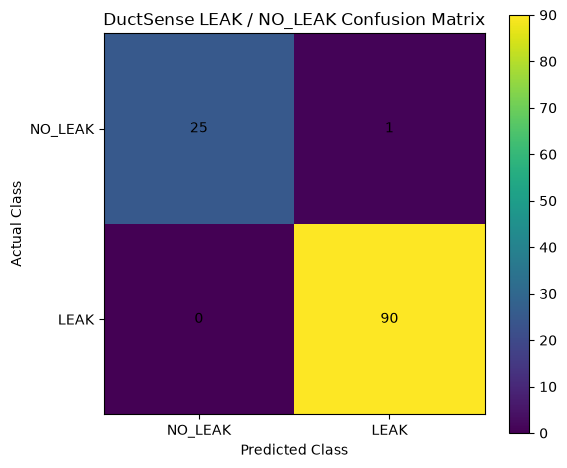

Confusion matrix saved to:
C:\Users\jyo6n\duct-sense\ml-training\audio\output\confusion_matrix.png


In [25]:
# ============================================================
# CELL 24 — SAVE CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "DuctSense LEAK / NO_LEAK Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    [0, 1],
    ["NO_LEAK", "LEAK"]
)

plt.yticks(
    [0, 1],
    ["NO_LEAK", "LEAK"]
)


for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.colorbar()

plt.tight_layout()


CONFUSION_MATRIX_PATH = (
    OUTPUT_DIR
    / "confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Confusion matrix saved to:"
)

print(
    CONFUSION_MATRIX_PATH
)

In [26]:
# ============================================================
# CELL 25 — NO_LEAK PERFORMANCE BY ENVIRONMENT
# ============================================================

print("=" * 65)
print("NO_LEAK PERFORMANCE BY RECORDING")
print("=" * 65)

for source in [
    "RoomTone2",
    "EmptyMall"
]:

    mask = (
        test_source_list == source
    )

    actual = y_test[mask]
    predicted = y_pred[mask]

    # NO_LEAK is class 0
    no_leak_correct = np.sum(
        predicted == 0
    )

    total = len(actual)

    accuracy_source = (
        no_leak_correct / total
        if total > 0
        else 0
    )

    false_leak_rate = (
        np.sum(predicted == 1) / total
        if total > 0
        else 0
    )

    print(
        f"\n{source}"
    )

    print(
        "Samples:",
        total
    )

    print(
        "Correctly classified NO_LEAK:",
        no_leak_correct
    )

    print(
        f"NO_LEAK accuracy: "
        f"{accuracy_source:.4f}"
    )

    print(
        f"False LEAK rate: "
        f"{false_leak_rate:.4f}"
    )

NO_LEAK PERFORMANCE BY RECORDING

RoomTone2
Samples: 20
Correctly classified NO_LEAK: 20
NO_LEAK accuracy: 1.0000
False LEAK rate: 0.0000

EmptyMall
Samples: 6
Correctly classified NO_LEAK: 5
NO_LEAK accuracy: 0.8333
False LEAK rate: 0.1667


In [27]:
# ============================================================
# CELL 26 — LEAK RECALL BY IICA LEAK TYPE
# ============================================================
#
# This tells us whether the binary model detects:
#
#   TUBELEAK
#   VENTLEAK
#   VENTLOW
#
# equally well.
# ============================================================

print("=" * 65)
print("LEAK PERFORMANCE BY IICA LEAK TYPE")
print("=" * 65)

for leak_type in [
    "TUBELEAK",
    "VENTLEAK",
    "VENTLOW"
]:

    mask = (
        test_leak_type_list == leak_type
    )

    actual = y_test[mask]
    predicted = y_pred[mask]

    detected = np.sum(
        predicted == LEAK
    )

    total = len(actual)

    recall_type = (
        detected / total
        if total > 0
        else 0
    )

    print(
        f"{leak_type:10s} | "
        f"Detected={detected:3d} / "
        f"{total:3d} | "
        f"Recall={recall_type:.4f}"
    )

LEAK PERFORMANCE BY IICA LEAK TYPE
TUBELEAK   | Detected= 30 /  30 | Recall=1.0000
VENTLEAK   | Detected= 30 /  30 | Recall=1.0000
VENTLOW    | Detected= 30 /  30 | Recall=1.0000


In [28]:
# ============================================================
# CELL 27 — LEAK PROBABILITY THRESHOLD ANALYSIS
# ============================================================
#
# Random Forest normally uses:
#
#     LEAK if probability >= 0.50
#
# But for DuctSense, threshold selection matters.
#
# Lower threshold:
#     -> more leaks detected
#     -> more false alarms
#
# Higher threshold:
#     -> fewer false alarms
#     -> potentially more missed leaks
# ============================================================

thresholds = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

threshold_results = []

for threshold in thresholds:

    threshold_prediction = (
        leak_probability >= threshold
    ).astype(int)

    accuracy_t = accuracy_score(
        y_test,
        threshold_prediction
    )

    recall_t = recall_score(
        y_test,
        threshold_prediction,
        zero_division=0
    )

    # NO_LEAK false-positive rate
    no_leak_mask = (
        y_test == NO_LEAK
    )

    if np.sum(no_leak_mask) > 0:

        false_positive_rate = (
            np.sum(
                threshold_prediction[
                    no_leak_mask
                ] == LEAK
            )
            /
            np.sum(no_leak_mask)
        )

    else:

        false_positive_rate = 0


    threshold_results.append({

        "threshold": threshold,

        "accuracy": accuracy_t,

        "leak_recall": recall_t,

        "no_leak_false_positive_rate":
            false_positive_rate
    })


threshold_df = pd.DataFrame(
    threshold_results
)

print(
    threshold_df.to_string(
        index=False
    )
)

 threshold  accuracy  leak_recall  no_leak_false_positive_rate
       0.2  0.982759     1.000000                     0.076923
       0.3  0.991379     1.000000                     0.038462
       0.4  0.991379     1.000000                     0.038462
       0.5  0.991379     1.000000                     0.038462
       0.6  0.991379     1.000000                     0.038462
       0.7  1.000000     1.000000                     0.000000
       0.8  0.991379     0.988889                     0.000000
       0.9  0.991379     0.988889                     0.000000


In [29]:
# ============================================================
# CELL 28 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_names = (

    [
        f"MFCC_{i+1}_mean"
        for i in range(13)
    ]

    +

    [
        f"MFCC_{i+1}_std"
        for i in range(13)
    ]

    +

    [
        "Centroid_mean",
        "Centroid_std",
        "Bandwidth_mean",
        "Bandwidth_std"
    ]
)

assert len(feature_names) == 30

feature_importance_df = pd.DataFrame({

    "feature":
        feature_names,

    "importance":
        model.feature_importances_

})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    feature_importance_df.head(15)
    .to_string(index=False)
)

       feature  importance
   MFCC_2_mean    0.226759
 Centroid_mean    0.164744
Bandwidth_mean    0.139363
   MFCC_1_mean    0.086444
   MFCC_4_mean    0.081190
   MFCC_3_mean    0.049033
   MFCC_5_mean    0.040151
   MFCC_7_mean    0.036311
   MFCC_6_mean    0.024060
  MFCC_10_mean    0.022185
    MFCC_7_std    0.016012
    MFCC_4_std    0.014712
  MFCC_13_mean    0.014637
   MFCC_10_std    0.012043
  MFCC_11_mean    0.011844


In [30]:
# ============================================================
# CELL 29 — SAVE MODEL AND ALL TRAINING OUTPUTS
# ============================================================

print("=" * 70)
print("SAVING DUCTSENSE AUDIO MODEL OUTPUTS")
print("=" * 70)


# ============================================================
# 1. MODEL
# ============================================================

MODEL_PATH = (
    MODEL_DIR
    / "ductsense_binary_rf_v2.pkl"
)


model_package = {

    "model": model,

    "sample_rate": SR,

    "window_seconds": WINDOW_SEC,

    "window_samples": WINDOW_SAMPLES,

    "feature_names": feature_names,

    "classes": CLASS_NAMES,

    "threshold": 0.50
}


joblib.dump(
    model_package,
    MODEL_PATH
)


print(
    "\nModel saved:"
)

print(
    MODEL_PATH
)


# ============================================================
# 2. MODEL METADATA
# ============================================================

MODEL_META_PATH = (
    MODEL_DIR
    / "ductsense_binary_rf_v2_meta.json"
)


metadata = {

    "model_type": "RandomForestClassifier",

    "task": "binary acoustic leak detection",

    "classes": CLASS_NAMES,

    "sample_rate": SR,

    "window_seconds": WINDOW_SEC,

    "window_samples": WINDOW_SAMPLES,

    "feature_count": len(feature_names),

    "features": feature_names,

    "decision_threshold": 0.50,

    "n_estimators": 300,

    "max_depth": 12,

    "class_weight": "balanced",

    "random_seed": SEED
}


with open(
    MODEL_META_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=2
    )


# ============================================================
# 3. MAIN METRICS
# ============================================================

metrics_path = (
    OUTPUT_DIR
    / "metrics.txt"
)


with open(
    metrics_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "DuctSense Binary Acoustic Leak Detection\n"
    )

    f.write(
        "=" * 60 + "\n\n"
    )

    f.write(
        f"Sample rate: {SR} Hz\n"
    )

    f.write(
        f"Window: {WINDOW_SEC} seconds\n"
    )

    f.write(
        f"Feature count: {len(feature_names)}\n\n"
    )

    f.write(
        f"Accuracy: {accuracy:.6f}\n"
    )

    f.write(
        f"Balanced Accuracy: "
        f"{balanced_accuracy:.6f}\n"
    )

    f.write(
        f"Precision: {precision:.6f}\n"
    )

    f.write(
        f"LEAK Recall: {leak_recall:.6f}\n"
    )

    f.write(
        f"F1 Score: {f1:.6f}\n"
    )

    f.write(
        f"NO_LEAK Specificity: "
        f"{no_leak_specificity:.6f}\n"
    )

    f.write(
        f"NO_LEAK False Positive Rate: "
        f"{no_leak_fpr:.6f}\n"
    )

    f.write(
        "\nConfusion Matrix:\n"
    )

    f.write(
        str(cm)
    )

    f.write(
        "\n\nClassification Report:\n"
    )

    f.write(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "NO_LEAK",
                "LEAK"
            ],
            zero_division=0
        )
    )


# ============================================================
# 4. THRESHOLD RESULTS
# ============================================================

threshold_path = (
    OUTPUT_DIR
    / "threshold_results.csv"
)

threshold_df.to_csv(
    threshold_path,
    index=False
)


# ============================================================
# 5. FEATURE IMPORTANCE
# ============================================================

feature_importance_path = (
    OUTPUT_DIR
    / "feature_importance.csv"
)

feature_importance_df.to_csv(
    feature_importance_path,
    index=False
)


# ============================================================
# 6. TEST PREDICTIONS
# ============================================================

test_predictions_df = pd.DataFrame({

    "source": test_source_list,

    "leak_type": test_leak_type_list,

    "actual_label": y_test,

    "actual_class": [
        CLASS_NAMES[i]
        for i in y_test
    ],

    "predicted_label": y_pred,

    "predicted_class": [
        CLASS_NAMES[i]
        for i in y_pred
    ],

    "leak_probability": leak_probability
})


test_predictions_path = (
    OUTPUT_DIR
    / "test_predictions.csv"
)

test_predictions_df.to_csv(
    test_predictions_path,
    index=False
)


# ============================================================
# 7. NO_LEAK ENVIRONMENT RESULTS
# ============================================================

no_leak_environment_rows = []

for source in [
    "RoomTone2",
    "EmptyMall"
]:

    mask = (
        test_source_list == source
    )

    actual = y_test[mask]

    predicted = y_pred[mask]

    total = len(actual)

    correct = np.sum(
        predicted == NO_LEAK
    )

    false_leaks = np.sum(
        predicted == LEAK
    )

    no_leak_accuracy = (
        correct / total
        if total > 0
        else 0
    )

    false_leak_rate = (
        false_leaks / total
        if total > 0
        else 0
    )

    no_leak_environment_rows.append({

        "environment": source,

        "samples": total,

        "correct_no_leak": correct,

        "false_leak": false_leaks,

        "no_leak_accuracy":
            no_leak_accuracy,

        "false_leak_rate":
            false_leak_rate
    })


no_leak_environment_df = pd.DataFrame(
    no_leak_environment_rows
)

no_leak_environment_path = (
    OUTPUT_DIR
    / "no_leak_environment_results.csv"
)

no_leak_environment_df.to_csv(
    no_leak_environment_path,
    index=False
)


# ============================================================
# 8. LEAK TYPE RESULTS
# ============================================================

leak_type_rows = []

for leak_type in [
    "TUBELEAK",
    "VENTLEAK",
    "VENTLOW"
]:

    mask = (
        test_leak_type_list == leak_type
    )

    actual = y_test[mask]

    predicted = y_pred[mask]

    total = len(actual)

    detected = np.sum(
        predicted == LEAK
    )

    recall_type = (
        detected / total
        if total > 0
        else 0
    )

    leak_type_rows.append({

        "leak_type": leak_type,

        "samples": total,

        "detected": detected,

        "missed": total - detected,

        "recall": recall_type
    })


leak_type_df = pd.DataFrame(
    leak_type_rows
)

leak_type_path = (
    OUTPUT_DIR
    / "leak_type_results.csv"
)

leak_type_df.to_csv(
    leak_type_path,
    index=False
)


# ============================================================
# FINAL CHECK
# ============================================================

print("\n" + "=" * 70)
print("OUTPUTS SAVED")
print("=" * 70)

for path in sorted(
    OUTPUT_DIR.iterdir()
):

    print(
        path.name
    )


print("\nModel:")
print(MODEL_PATH)

print("\nMetadata:")
print(MODEL_META_PATH)

SAVING DUCTSENSE AUDIO MODEL OUTPUTS

Model saved:
C:\Users\jyo6n\duct-sense\models\audio\ductsense_binary_rf_v2.pkl

OUTPUTS SAVED
.gitkeep
confusion_matrix.png
feature_importance.csv
leak_type_results.csv
metrics.txt
no_leak_environment_results.csv
test_predictions.csv
threshold_results.csv

Model:
C:\Users\jyo6n\duct-sense\models\audio\ductsense_binary_rf_v2.pkl

Metadata:
C:\Users\jyo6n\duct-sense\models\audio\ductsense_binary_rf_v2_meta.json


In [31]:
# ============================================================
# CELL 30 — SINGLE FILE INFERENCE
# ============================================================

def predict_audio_file(
    audio_path,
    threshold=0.50
):

    audio_path = Path(
        audio_path
    )

    if not audio_path.exists():

        raise FileNotFoundError(
            f"Audio file not found:\n{audio_path}"
        )


    # --------------------------------------------------------
    # LOAD AUDIO
    # --------------------------------------------------------

    audio, _ = librosa.load(
        audio_path,
        sr=SR,
        mono=True
    )


    # --------------------------------------------------------
    # FORCE 2 SECOND INPUT
    # --------------------------------------------------------

    if len(audio) < WINDOW_SAMPLES:

        audio = np.pad(
            audio,
            (
                0,
                WINDOW_SAMPLES - len(audio)
            )
        )

    else:

        audio = audio[
            :WINDOW_SAMPLES
        ]


    # --------------------------------------------------------
    # FEATURES
    # --------------------------------------------------------

    features = extract_features(
        audio
    )

    features = features.reshape(
        1,
        -1
    )


    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    probability = model.predict_proba(
        features
    )[0, 1]


    prediction = (
        "LEAK"
        if probability >= threshold
        else "NO_LEAK"
    )


    return prediction, probability


# ============================================================
# TEST CURRENT NO_LEAK FILES
# ============================================================

prediction, probability = predict_audio_file(
    ROOMTONE_PATH
)

print("\nRoomTone2")
print("Prediction:", prediction)
print(
    f"LEAK probability: {probability:.4f}"
)


prediction, probability = predict_audio_file(
    MALL_PATH
)

print("\nEmpty Mall")
print("Prediction:", prediction)
print(
    f"LEAK probability: {probability:.4f}"
)


RoomTone2
Prediction: NO_LEAK
LEAK probability: 0.0033

Empty Mall
Prediction: NO_LEAK
LEAK probability: 0.0000


In [32]:
# ============================================================
# CELL 31 — FINAL ARTIFACT AUDIT
# ============================================================

print("=" * 70)
print("DUCTSENSE AUDIO MODEL — FINAL ARTIFACT AUDIT")
print("=" * 70)


# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------

assert MODEL_PATH.exists(), (
    "Trained model was not created."
)

assert MODEL_META_PATH.exists(), (
    "Model metadata was not created."
)


# ------------------------------------------------------------
# OUTPUTS
# ------------------------------------------------------------

required_outputs = [

    OUTPUT_DIR / "metrics.txt",

    OUTPUT_DIR / "confusion_matrix.png",

    OUTPUT_DIR / "threshold_results.csv",

    OUTPUT_DIR / "feature_importance.csv",

    OUTPUT_DIR / "test_predictions.csv",

    OUTPUT_DIR / "no_leak_environment_results.csv",

    OUTPUT_DIR / "leak_type_results.csv"
]


for path in required_outputs:

    assert path.exists(), (
        f"Missing output artifact:\n{path}"
    )


# ------------------------------------------------------------
# RELOAD MODEL
# ------------------------------------------------------------

loaded_package = joblib.load(
    MODEL_PATH
)

loaded_model = loaded_package["model"]

print("\nModel reload: PASS")


# ------------------------------------------------------------
# VERIFY INFERENCE AFTER RELOAD
# ------------------------------------------------------------

test_audio = ROOMTONE_PATH

audio, _ = librosa.load(
    test_audio,
    sr=SR,
    mono=True
)

if len(audio) < WINDOW_SAMPLES:

    audio = np.pad(
        audio,
        (
            0,
            WINDOW_SAMPLES - len(audio)
        )
    )

else:

    audio = audio[
        :WINDOW_SAMPLES
    ]


features = extract_features(
    audio
)

features = features.reshape(
    1,
    -1
)

reloaded_probability = (
    loaded_model
    .predict_proba(features)[0, 1]
)

reloaded_prediction = (
    "LEAK"
    if reloaded_probability >= 0.50
    else "NO_LEAK"
)


print(
    "Reloaded inference: PASS"
)

print(
    "RoomTone2 prediction:",
    reloaded_prediction
)

print(
    f"RoomTone2 LEAK probability: "
    f"{reloaded_probability:.4f}"
)


# ------------------------------------------------------------
# FILE SIZES
# ------------------------------------------------------------

print("\nMODEL FILE:")
print(
    MODEL_PATH,
    "->",
    round(
        MODEL_PATH.stat().st_size / 1024,
        2
    ),
    "KB"
)


print("\nOUTPUT DIRECTORY:")

for path in sorted(
    OUTPUT_DIR.iterdir()
):

    if path.is_file():

        print(
            f"{path.name:40s}"
            f"{path.stat().st_size / 1024:.2f} KB"
        )


print("\n" + "=" * 70)
print("PASS — DUCTSENSE AUDIO TRAINING PIPELINE COMPLETED")
print("=" * 70)

DUCTSENSE AUDIO MODEL — FINAL ARTIFACT AUDIT

Model reload: PASS
Reloaded inference: PASS
RoomTone2 prediction: NO_LEAK
RoomTone2 LEAK probability: 0.0033

MODEL FILE:
C:\Users\jyo6n\duct-sense\models\audio\ductsense_binary_rf_v2.pkl -> 416.03 KB

OUTPUT DIRECTORY:
.gitkeep                                0.00 KB
confusion_matrix.png                    46.60 KB
feature_importance.csv                  1.01 KB
leak_type_results.csv                   0.10 KB
metrics.txt                             0.74 KB
no_leak_environment_results.csv         0.16 KB
test_predictions.csv                    4.73 KB
threshold_results.csv                   0.41 KB

PASS — DUCTSENSE AUDIO TRAINING PIPELINE COMPLETED
